# 02_exploracion_clima_ideam_siata
## Exploración y Preparación de Datos Ambientales y Climáticos — VitalRisk AI (Equipo 326)

| Metadato | Valor |
|---|---|
| **Fase ASUM-ML** | Exploración + Preparación de Datos (Pasos 2-3 de ADR002) |
| **HUs que cierra** | HU5 (extracción ambiental) + HU6 (limpieza ambiental) |
| **Insumo para** | HU7 — cruce IRA × clima en `04_merge_datos.ipynb` |
| **Output** | `clean_calidad_aire.csv` → carga en `fact_calidad_aire` |
| **Compañero** | Ver `01_exploracion_IRA_ESI.ipynb` para la variable objetivo |


# **1. Entendimiento del Negocio**

En el Valle de Aburrá, la calidad del aire y las condiciones meteorológicas son
**detonantes físicos documentados de los brotes de IRA**. El material particulado
fino (PM2.5) penetra el tracto respiratorio inferior y aumenta la susceptibilidad
a infecciones; la baja temperatura y la alta humedad favorecen la supervivencia
de patógenos; la precipitación y la presión influyen en la dispersión de contaminantes.

VitalRisk AI necesita estas variables para que el modelo XGBoost identifique
**qué combinaciones ambientales anteceden en 1-2 semanas a los picos de IRA**,
y genere el Índice Preventivo Territorial (IPT) y las alertas automáticas (HU15).

Este notebook construye esa capa ambiental desde las fuentes oficiales del IDEAM
(Plan B confirmado, mientras se espera respuesta del SIATA — radicado 021682).


# **2. Enfoque Analítico**

Transformar múltiples series de tiempo de alta resolución (registros sub-diarios
de estaciones meteorológicas e hidrometeorológicas) en un **dataset analítico
estandarizado con granularidad municipio × semana epidemiológica**, compatible
con la capa epidemiológica del notebook 01 y con el esquema `fact_calidad_aire`
del `init.sql` v3.

**Unidad de análisis objetivo:** par `(codigo_dane, anio, semana_epi)`.

**Criterios de éxito:**
- Los 10 municipios del Valle de Aburrá tienen datos para ≥95% de semanas 2018-2023.
- PM2.5 y PM10 disponibles para 2018-2023 con imputación documentada para 2018-2019.
- `fuente_pm` trazabiliza origen directo (`SISAIRE_DIRECTO`) vs imputado (`IMPUTADO_PA`).
- El CSV pasa validaciones de rango físico y unicidad de llave.

**Decisión metodológica (ADR002):** el SISAIRE granulado solo cubre 2020-2024.
Para 2018-2019 se usa el Promedio Anual (PA) como ancla estadística, generando
52 valores semanales ~ Normal(media_PA, std_estimada_de_años_reales).
Esto preserva los 2 primeros años del período de entrenamiento del modelo.


# **3. Requerimientos de Datos**

| # | Dataset | Sistema | Archivo `.csv` | Variables clave |
|---|---|---|---|---|
| 1 | Calidad del Aire — Granulado | SISAIRE / IDEAM | `Calidad_del_Aire_en_Colombia.csv` | PM2.5, PM10 (`MSFL_CODE`), `MED_CONCENTRACION_ESTANDAR`, `MED_FECHA_INICIO`, `LATITUD`, `LONGITUD` |
| 2 | Calidad del Aire — Promedio Anual | SISAIRE / IDEAM | `Calidad_del_Aire_en_Colombia_PA.csv` | `Promedio`, `Año`, `Variable`, `Código del Municipio` |
| 3 | Temperatura Ambiente del Aire | DHIME / IDEAM | `Temperatura_Ambiente_del_Aire.csv` | `CodigoEstacion`, `FechaObservacion`, `ValorObservado`, `Latitud`, `Longitud` |
| 4 | Humedad del Aire | DHIME / IDEAM | `Humedad_del_Aire.csv` | ídem — sensor: 'Humedad del aire 2 mt' |
| 5 | Precipitación | DHIME / IDEAM | `Precipitacion.csv` | ídem — sensor: 'Precipitacion' |
| 6 | Presión Atmosférica | DHIME / IDEAM | `Presion_Atmosferica.csv` | ídem — sensor: 'Presión Atmosferica (1h)' |
| 7 | Geometrías municipales | NB03 | `clean_municipios.geojson` | `codigo_dane`, `geometry` |

**Restricciones:** Antioquia únicamente · Período 2018-2023 · Sensores de superficie.

**Advertencia — IDs incompatibles:** SISAIRE usa `ESTACION_ID` de 4-5 dígitos;
DHIME usa `CodigoEstacion` de 8 dígitos. No son cruzables por ID.
El puente estación→municipio se resuelve por **spatial join** de coordenadas.


# **4. Adquisición de Datos**

Archivos descargados manualmente desde datos.gov.co en formato `.csv`.
Todos en `../data/raw/clima/`.

| Archivo | Peso aprox. | Filas |
|---|---|---|
| `Calidad_del_Aire_en_Colombia.csv` | ~1.5 GB | 7.6 M |
| `Precipitacion.csv` | ~3.0 GB | 20 M |
| `Temperatura_Ambiente_del_Aire.csv` | ~1.1 GB | 6.8 M |
| `Humedad_del_Aire.csv` | ~983 MB | 6.5 M |
| `Presion_Atmosferica.csv` | ~405 MB | 2.4 M |
| `Calidad_del_Aire_en_Colombia_PA.csv` | ~10 MB | 29 k |


In [1]:
# ── Librerías ──────────────────────────────────────────────────────────────
# pip install pandas geopandas openpyxl shapely
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from functools import reduce
import warnings
warnings.filterwarnings('ignore')

# ── Rutas ──────────────────────────────────────────────────────────────────
RAW_PATH       = Path('../data/raw/clima/')
PROCESSED_PATH = Path('../data/processed/')

# ── Parámetros globales ────────────────────────────────────────────────────
ANIO_MIN, ANIO_MAX = 2018, 2023

# Codigos DANE de los 10 municipios del Valle de Aburra
VALLE_ABURRA = {
    '05001': 'MEDELLIN',  '05088': 'BELLO',     '05129': 'CALDAS',
    '05212': 'COPACABANA','05266': 'ENVIGADO',  '05308': 'GIRARDOTA',
    '05360': 'ITAGUI',    '05380': 'LA ESTRELLA','05631': 'SABANETA',
    '05837': 'BARBOSA'
}

# ── Geometrías municipales (procesadas en notebook 03) ─────────────────────
gdf_municipios = gpd.read_file(PROCESSED_PATH / 'clean_municipios.geojson')
print(f'Municipios cargados: {len(gdf_municipios)}')
print(f'CRS: {gdf_municipios.crs}')


Municipios cargados: 125
CRS: EPSG:4326


In [2]:
# ── Carga de datasets brutos ───────────────────────────────────────────────
print('Cargando archivos... (los archivos grandes toman tiempo)')

cols_ca = ['ESTACION_ID','MSFL_CODE','MED_CONCENTRACION_ESTANDAR',
           'MED_FECHA_INICIO','LATITUD','LONGITUD',
           'CODIGO_MUNICIPIO','MUNICIPIO','DEPARTAMENTO']
df_ca   = pd.read_csv(RAW_PATH / 'Calidad_del_Aire_en_Colombia.csv',
                      usecols=cols_ca, dtype={'CODIGO_MUNICIPIO': str})
df_pa   = pd.read_csv(RAW_PATH / 'Calidad_del_Aire_en_Colombia_PA.csv')
df_temp = pd.read_csv(RAW_PATH / 'Temperatura_Ambiente_del_Aire.csv')
df_hum  = pd.read_csv(RAW_PATH / 'Humedad_del_Aire.csv')
df_prec = pd.read_csv(RAW_PATH / 'Precipitacion.csv')
df_pres = pd.read_csv(RAW_PATH / 'Presion_Atmosferica.csv')

print('Todos los archivos cargados correctamente')


Cargando archivos... (los archivos grandes toman tiempo)
Todos los archivos cargados correctamente


# **5. Entendimiento de los Datos**

### 5.1 Cobertura temporal real por fuente
### 5.2 Análisis de nulidad por fuente
### 5.3 Distribuciones de variables clave
### 5.4 Diagnóstico de cobertura espacial
### 5.5 Hallazgos y decisiones metodológicas


In [3]:
# ── 5.1 Cobertura temporal por fuente ─────────────────────────────────────
def parsear_fecha(df, col):
    df = df.copy()
    df['fecha'] = pd.to_datetime(df[col], format='mixed', errors='coerce') 
    return df

df_ca   = parsear_fecha(df_ca,   'MED_FECHA_INICIO')
df_temp = parsear_fecha(df_temp, 'FechaObservacion')
df_hum  = parsear_fecha(df_hum,  'FechaObservacion')
df_prec = parsear_fecha(df_prec, 'FechaObservacion')
df_pres = parsear_fecha(df_pres, 'FechaObservacion')

print("Funciono")

Funciono


In [4]:

fuentes = {
    'SISAIRE granulado (PM)': df_ca,
    'DHIME Temperatura':      df_temp,
    'DHIME Humedad':          df_hum,
    'DHIME Precipitacion':    df_prec,
    'DHIME Presion':          df_pres,
}

print('=== COBERTURA TEMPORAL POR FUENTE ===')
for nombre, df in fuentes.items():
    rango_total_min = df['fecha'].min()
    rango_total_max = df['fecha'].max()
    df_rango = df[(df['fecha'].dt.year >= ANIO_MIN) & (df['fecha'].dt.year <= ANIO_MAX)]
    print(f'\n{nombre}:')
    print(f'  Rango total  : {rango_total_min.date()} -> {rango_total_max.date()}')
    print(f'  Filas 2018-23: {len(df_rango):,}')

# HALLAZGO DOCUMENTADO: SISAIRE granulado empieza en 2020, no 2018.
# Esto motiva la imputacion PA para 2018-2019 (seccion 6.4).


=== COBERTURA TEMPORAL POR FUENTE ===

SISAIRE granulado (PM):
  Rango total  : 2020-01-01 -> 2024-12-31
  Filas 2018-23: 6,034,271

DHIME Temperatura:
  Rango total  : 2005-01-01 -> 2026-06-19
  Filas 2018-23: 3,283,566

DHIME Humedad:
  Rango total  : 2004-11-19 -> 2026-06-19
  Filas 2018-23: 2,892,636

DHIME Precipitacion:
  Rango total  : 2005-01-01 -> 2026-06-19
  Filas 2018-23: 9,351,471

DHIME Presion:
  Rango total  : 2005-01-01 -> 2026-06-19
  Filas 2018-23: 473,761


In [5]:
# ── 5.2 Análisis de nulidad ───────────────────────────────────────────────
COLS_USO = {
    'SISAIRE granulado (PM)': ['ESTACION_ID','MSFL_CODE',
                                'MED_CONCENTRACION_ESTANDAR','fecha',
                                'LATITUD','LONGITUD'],
    'DHIME Temperatura': ['CodigoEstacion','ValorObservado','fecha',
                           'Latitud','Longitud','DescripcionSensor'],
    'DHIME Humedad':     ['CodigoEstacion','ValorObservado','fecha',
                           'Latitud','Longitud','DescripcionSensor'],
    'DHIME Precipitacion':['CodigoEstacion','ValorObservado','fecha',
                           'Latitud','Longitud','DescripcionSensor'],
    'DHIME Presion':     ['CodigoEstacion','ValorObservado','fecha',
                           'Latitud','Longitud','DescripcionSensor'],
}


In [6]:
dfs_map = {
    'SISAIRE granulado (PM)': df_ca,
    'DHIME Temperatura': df_temp,
    'DHIME Humedad': df_hum,
    'DHIME Precipitacion': df_prec,
    'DHIME Presion': df_pres,
}

print('=== ANALISIS DE NULIDAD (columnas en uso) ===\n')
for nombre, df in dfs_map.items():
    cols = [c for c in COLS_USO[nombre] if c in df.columns]
    nulos = df[cols].isnull().sum()
    nulos = nulos[nulos > 0]
    print(f'{nombre}:')
    if len(nulos) == 0:
        print('  Sin nulos en columnas de uso')
    else:
        for col in nulos.index:
            pct = nulos[col] / len(df) * 100
            print(f'  {col}: {nulos[col]:,} nulos ({pct:.1f}%)')
    print()

=== ANALISIS DE NULIDAD (columnas en uso) ===

SISAIRE granulado (PM):
  Sin nulos en columnas de uso

DHIME Temperatura:
  Sin nulos en columnas de uso

DHIME Humedad:
  Sin nulos en columnas de uso

DHIME Precipitacion:
  Sin nulos en columnas de uso

DHIME Presion:
  Sin nulos en columnas de uso



In [7]:
# ── 5.3 Distribuciones de variables clave (Antioquia 2018-2023) ──────────
def filtrar_antioquia_rango(df, col_dept='Departamento'):
    df = df[df[col_dept].str.upper() == 'ANTIOQUIA'].copy()
    df = df[(df['fecha'].dt.year >= ANIO_MIN) & (df['fecha'].dt.year <= ANIO_MAX)]
    df['ValorObservado'] = pd.to_numeric(df['ValorObservado'], errors='coerce')
    return df.dropna(subset=['ValorObservado'])

df_temp_ant = filtrar_antioquia_rango(df_temp)
df_hum_ant  = filtrar_antioquia_rango(df_hum)
df_prec_ant = filtrar_antioquia_rango(df_prec)
df_pres_ant = filtrar_antioquia_rango(df_pres)


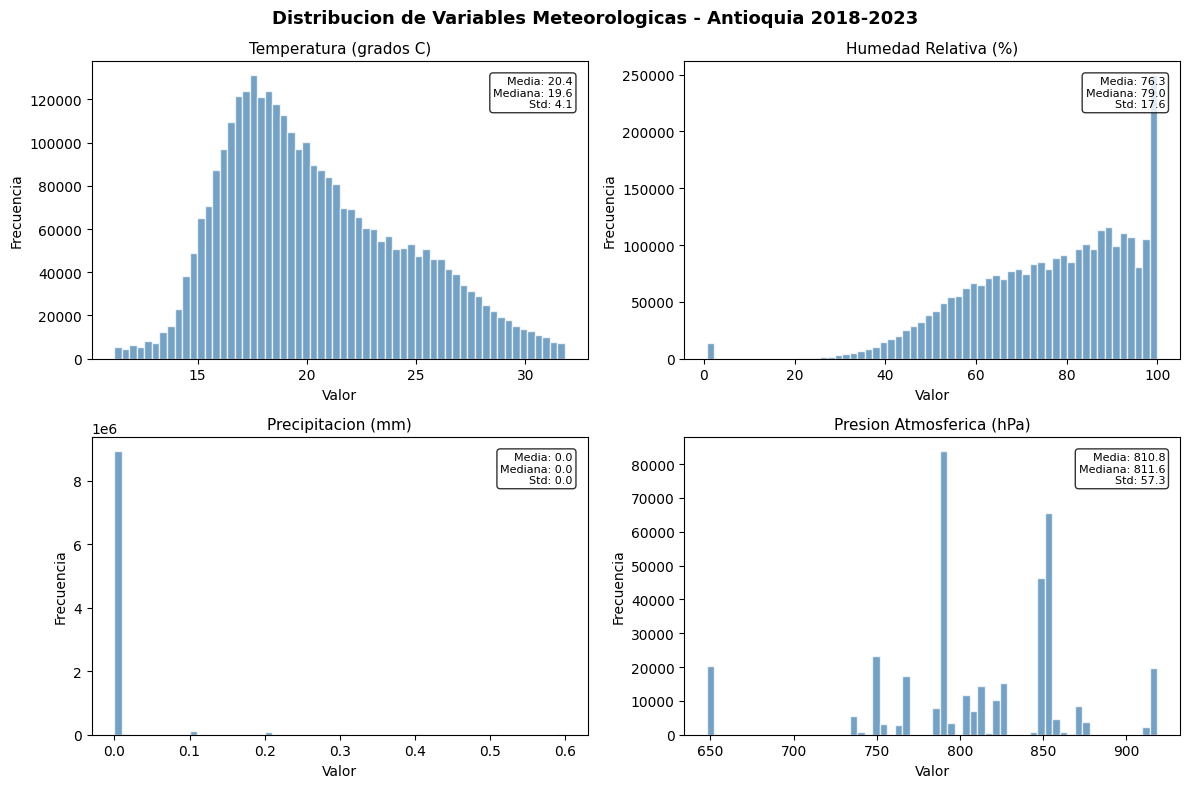

In [8]:
# Humedad: excluir sensores de suelo
df_hum_ant = df_hum_ant[
    df_hum_ant['DescripcionSensor'].str.upper().str.contains('AIRE|RELATIVA', na=False)]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribucion de Variables Meteorologicas - Antioquia 2018-2023',
             fontsize=13, fontweight='bold')

pares = [
    (df_temp_ant,  'Temperatura (grados C)',      axes[0,0], -10, 45),
    (df_hum_ant,   'Humedad Relativa (%)',         axes[0,1],   0, 100),
    (df_prec_ant,  'Precipitacion (mm)',            axes[1,0],   0, 500),
    (df_pres_ant,  'Presion Atmosferica (hPa)',    axes[1,1], 500, 1100),
]

for df, titulo, ax, rmin, rmax in pares:
    datos = df['ValorObservado'].dropna()
    datos_vis = datos[(datos >= rmin) & (datos <= rmax)]
    p1, p99 = datos_vis.quantile(0.01), datos_vis.quantile(0.99)
    datos_vis = datos_vis[(datos_vis >= p1) & (datos_vis <= p99)]
    ax.hist(datos_vis, bins=60, color='steelblue', alpha=0.75, edgecolor='white')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    stats = f'Media: {datos_vis.mean():.1f}\nMediana: {datos_vis.median():.1f}\nStd: {datos_vis.std():.1f}'
    ax.text(0.97, 0.95, stats, transform=ax.transAxes,
            va='top', ha='right', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [9]:
# ── 5.4 Cobertura espacial de estaciones ──────────────────────────────────
df_pm_ant = df_ca[
    (df_ca['MSFL_CODE'].isin(['PM2.5', 'PM10'])) &
    (df_ca['fecha'].dt.year.between(ANIO_MIN, ANIO_MAX)) &
    (df_ca['DEPARTAMENTO'].str.upper() == 'ANTIOQUIA')
].copy()
df_pm_ant['MED_CONCENTRACION_ESTANDAR'] = pd.to_numeric(
    df_pm_ant['MED_CONCENTRACION_ESTANDAR'], errors='coerce')

print('=== COBERTURA ESPACIAL ===')
print(f'Estaciones DHIME Temperatura  : {df_temp_ant["CodigoEstacion"].nunique()}')
print(f'Estaciones DHIME Humedad      : {df_hum_ant["CodigoEstacion"].nunique()}')
print(f'Estaciones DHIME Precipitacion: {df_prec_ant["CodigoEstacion"].nunique()}')
print(f'Estaciones DHIME Presion      : {df_pres_ant["CodigoEstacion"].nunique()}')
print(f'Estaciones SISAIRE PM         : {df_pm_ant["ESTACION_ID"].nunique()}')
print(f'Municipios en GeoJSON         : {len(gdf_municipios)}')


=== COBERTURA ESPACIAL ===
Estaciones DHIME Temperatura  : 35
Estaciones DHIME Humedad      : 35
Estaciones DHIME Precipitacion: 62
Estaciones DHIME Presion      : 14
Estaciones SISAIRE PM         : 84
Municipios en GeoJSON         : 125


### 5.5 Hallazgos y decisiones metodológicas

| Hallazgo | Decisión |
|---|---|
| SISAIRE granulado cubre solo **2020-2024** | Imputar PM 2018-2019 desde PA + varianza de años reales. Columna `fuente_pm = 'IMPUTADO_PA'` |
| IDs **incompatibles** entre SISAIRE y DHIME | Cruce estacion→municipio por **spatial join** de coordenadas |
| Humedad mezcla sensores de aire y de suelo | Filtrar por `DescripcionSensor` que contenga 'AIRE' o 'RELATIVA' |
| 11 registros precipitacion > 2000 mm/semana | Winsorizar al p99 antes del merge |
| Presion cubre solo 16 estaciones (~15% registros) | Aceptable en Valle de Aburra (altitud similar). Documentado como limitacion. |


# **6. Preparación de los Datos**

### 6.1 Cruce espacial estacion → municipio (spatial join)
### 6.2 Agregacion semanal — variables meteorologicas DHIME
### 6.3 Agregacion semanal — PM2.5 y PM10 SISAIRE (2020-2023)
### 6.4 Imputacion PM 2018-2019 usando Promedio Anual (PA)
### 6.5 Consolidacion y winsorizacion de outliers
### 6.6 Validacion final y exportacion


In [10]:
# ── 6.1 Cruce espacial estacion → municipio ───────────────────────────────
# Estrategia:
# 1) sjoin 'within': la estacion cae dentro de un poligono municipal.
# 2) sjoin_nearest como fallback para estaciones en bordes o con coordenada
#    levemente desplazada (aceptamos hasta 0.5 grados ~ 55 km).
# Operamos solo sobre el catalogo de estaciones unicas, no sobre millones de filas.

def asignar_municipio(df_raw, lat_col, lon_col, id_col, gdf_muni, label):
    est = df_raw[[id_col, lat_col, lon_col]].drop_duplicates()
    est = est.dropna(subset=[lat_col, lon_col])
    est[lat_col] = pd.to_numeric(est[lat_col], errors='coerce')
    est[lon_col] = pd.to_numeric(est[lon_col], errors='coerce')
    est = est.dropna(subset=[lat_col, lon_col])

    gdf_est = gpd.GeoDataFrame(
        est,
        geometry=gpd.points_from_xy(est[lon_col], est[lat_col]),
        crs='EPSG:4326'
    )

    # Paso 1: within
    joined = gpd.sjoin(gdf_est, gdf_muni[['codigo_dane','geometry']],
                       how='left', predicate='within')

    # Paso 2: nearest para los no asignados
    no_asig = joined[joined['codigo_dane'].isna()][[id_col, lat_col, lon_col, 'geometry']].copy()
    if len(no_asig) > 0:
        fb = gpd.sjoin_nearest(no_asig, gdf_muni[['codigo_dane','geometry']],
                               how='left', distance_col='dist_grados')
        fb = fb[fb['dist_grados'] < 0.5]
        fb_idx = fb.set_index(id_col)['codigo_dane']
        mask_no = joined['codigo_dane'].isna() & joined[id_col].isin(fb_idx.index)
        joined.loc[mask_no, 'codigo_dane'] = joined.loc[mask_no, id_col].map(fb_idx)

    mapa = joined[[id_col, 'codigo_dane']].dropna().drop_duplicates()
    print(f'  {label}: {len(mapa)} estaciones asignadas a municipio')
    return mapa


In [11]:
print('Asignando municipios a estaciones...')
map_temp = asignar_municipio(df_temp_ant, 'Latitud', 'Longitud', 'CodigoEstacion', gdf_municipios, 'Temperatura')
map_hum  = asignar_municipio(df_hum_ant,  'Latitud', 'Longitud', 'CodigoEstacion', gdf_municipios, 'Humedad')
map_prec = asignar_municipio(df_prec_ant, 'Latitud', 'Longitud', 'CodigoEstacion', gdf_municipios, 'Precipitacion')
map_pres = asignar_municipio(df_pres_ant, 'Latitud', 'Longitud', 'CodigoEstacion', gdf_municipios, 'Presion')
map_pm   = asignar_municipio(df_pm_ant,   'LATITUD', 'LONGITUD', 'ESTACION_ID',    gdf_municipios, 'PM SISAIRE')

Asignando municipios a estaciones...
  Temperatura: 35 estaciones asignadas a municipio
  Humedad: 35 estaciones asignadas a municipio
  Precipitacion: 62 estaciones asignadas a municipio
  Presion: 14 estaciones asignadas a municipio
  PM SISAIRE: 84 estaciones asignadas a municipio


In [12]:
# ── Funcion auxiliar: semana epidemiologica ────────────────────────────────
# Aproximacion: semana ISO (lunes=dia 1). Diferencia con epi OPS: 0-1 dia.
def calc_semana_epi(serie_fecha):
    iso = serie_fecha.dt.isocalendar()
    return iso['year'].astype('int16'), iso['week'].astype('int8')


In [13]:
# ── 6.2 Agregacion semanal DHIME ──────────────────────────────────────────
def agregar_semanal(df, mapa_dane, id_col, val_col, col_salida, modo='mean'):
    df = df.merge(mapa_dane, on=id_col, how='inner')
    df = df[df['fecha'].dt.year.between(ANIO_MIN, ANIO_MAX)].copy()
    df[val_col] = pd.to_numeric(df[val_col], errors='coerce')
    df = df.dropna(subset=[val_col, 'codigo_dane'])
    df['anio'], df['semana_epi'] = calc_semana_epi(df['fecha'])
    resultado = (
        df.groupby(['codigo_dane','anio','semana_epi'])[val_col]
          .agg(modo)
          .round(3)
          .reset_index()
          .rename(columns={val_col: col_salida})
    )
    n = resultado['codigo_dane'].nunique()
    print(f'  {col_salida}: {len(resultado):,} registros | {n} municipios')
    return resultado


In [14]:
print('Agregando variables meteorologicas a nivel semanal...')
df_temp_sem = agregar_semanal(df_temp_ant, map_temp, 'CodigoEstacion', 'ValorObservado', 'temperatura_avg', 'mean')
df_hum_sem  = agregar_semanal(df_hum_ant,  map_hum,  'CodigoEstacion', 'ValorObservado', 'humedad_avg',     'mean')
df_prec_sem = agregar_semanal(df_prec_ant, map_prec, 'CodigoEstacion', 'ValorObservado', 'precipitacion_sum','sum')
df_pres_sem = agregar_semanal(df_pres_ant, map_pres, 'CodigoEstacion', 'ValorObservado', 'presion_avg',     'mean')

Agregando variables meteorologicas a nivel semanal...
  temperatura_avg: 4,426 registros | 30 municipios
  humedad_avg: 4,532 registros | 30 municipios
  precipitacion_sum: 7,641 registros | 50 municipios
  presion_avg: 1,846 registros | 14 municipios


In [15]:
# ── 6.3 PM2.5 y PM10 SISAIRE 2020-2023 ───────────────────────────────────
df_pm2 = df_pm_ant.merge(map_pm, on='ESTACION_ID', how='inner').copy()
df_pm2['MED_CONCENTRACION_ESTANDAR'] = pd.to_numeric(
    df_pm2['MED_CONCENTRACION_ESTANDAR'], errors='coerce')
df_pm2 = df_pm2.dropna(subset=['MED_CONCENTRACION_ESTANDAR','codigo_dane'])
df_pm2['anio'], df_pm2['semana_epi'] = calc_semana_epi(df_pm2['fecha'])

In [16]:
df_pm_sem = (
    df_pm2
    .groupby(['codigo_dane','anio','semana_epi','MSFL_CODE'])
    ['MED_CONCENTRACION_ESTANDAR'].mean()
    .round(3).reset_index()
    .pivot_table(index=['codigo_dane','anio','semana_epi'],
                 columns='MSFL_CODE', values='MED_CONCENTRACION_ESTANDAR')
    .reset_index()
    .rename(columns={'PM2.5':'pm25_avg','PM10':'pm10_avg'})
)
df_pm_sem['fuente_pm'] = 'SISAIRE_DIRECTO'

print(f'PM semanal SISAIRE 2020-2023: {len(df_pm_sem):,} registros')
print(f'Municipios con PM: {df_pm_sem["codigo_dane"].nunique()}')
print('Cobertura por anio:')
print(df_pm_sem.groupby('anio').size())


PM semanal SISAIRE 2020-2023: 2,911 registros
Municipios con PM: 29
Cobertura por anio:
anio
2020    643
2021    730
2022    756
2023    782
dtype: int64


In [20]:
df_pa.columns

Index(['ID Estacion', 'Autoridad Ambiental', 'Estación', 'Latitud', 'Longitud',
       'Variable', 'Unidades', 'Tiempo de exposición (horas)', 'Año',
       'Promedio', 'Suma', 'No. de datos', 'Representatividad Temporal',
       'Excedencias limite actual', 'Porcentaje excedencias limite actual',
       'Mediana', 'Percentil 98', 'Máximo', 'Fechas/horas del máximo',
       'Mínimo', 'Fechas/horas del mínimo', 'Días de excedencias',
       'Código del Departamento', 'Nombre del Departamento',
       'Código del Municipio', 'Nombre del Municipio', 'Tipo de Estación',
       'Ubicacion'],
      dtype='str')

In [17]:
# ── 6.4 Imputacion PM 2018-2019 usando Promedio Anual ─────────────────────
# El PA cubre 2011-2024 pero con granularidad anual.
# Estrategia: distribuir el promedio anual en 52 semanas con varianza
# estimada desde los datos SISAIRE reales 2020-2023 del mismo municipio.

df_pa_ant = df_pa[
    (df_pa['Nombre del Departamento'].str.upper() == 'ANTIOQUIA') &
    (df_pa['Variable'].isin(['PM2.5','PM10'])) &
    (df_pa['Año'].str.replace(',', '').astype(str).str.strip().isin(['2018','2019']))
].copy()

# AJUSTAR: la columna 'Año' puede llamarse 'Año' segun la codificacion del CSV.
# Si aparece error, cambiar 'Año' por el nombre real de la columna de anio.

df_pa_ant['Promedio'] = pd.to_numeric(df_pa_ant['Promedio'], errors='coerce')
df_pa_ant['codigo_dane'] = df_pa_ant['Código del Municipio'].apply(
    lambda x: f'{int(float(x)):05d}' if pd.notna(x) else None)
df_pa_ant['anio'] = df_pa_ant['Año'].str.replace(',', '').astype(str).str.strip().astype(int)

print(f'Registros PA para 2018-2019 en Antioquia: {len(df_pa_ant)}')
print(f'Municipios cubiertos por PA: {df_pa_ant["codigo_dane"].nunique()}')

pa_pivot = (
    df_pa_ant
    .groupby(['codigo_dane','anio','Variable'])['Promedio'].mean()
    .reset_index()
    .pivot_table(index=['codigo_dane','anio'], columns='Variable', values='Promedio')
    .reset_index()
    .rename(columns={'PM2.5':'media_pm25','PM10':'media_pm10'})
)


Registros PA para 2018-2019 en Antioquia: 326
Municipios cubiertos por PA: 39


In [31]:
df_pa_ant

,ID Estacion,Autoridad Ambiental,Estación,Latitud,Longitud,Variable,Unidades,Tiempo de exposición (horas),Año,Promedio,...,Fechas/horas del mínimo,Días de excedencias,Código del Departamento,Nombre del Departamento,Código del Municipio,Nombre del Municipio,Tipo de Estación,Ubicacion,codigo_dane,anio
720,"31,343",AMVA,TORRE SOCIAL,6.436667,-75.330556,PM2.5,ugm3,24,"2,018",12.4,...,6/10/2018 0:00,1,5,ANTIOQUIA,5079.0,BARBOSA,Fija,POINT (-75.330556 6.436667),05079,2018
5753,"31,406",CORANTIOQUIA,CA. PUERTO BERRÍO 2018_2,6.490278,-74.405833,PM10,ugm3,24,"2,018",11.7,...,8/03/2018,0,5,ANTIOQUIA,5579.0,PUERTO BERRÍO,Indicativa,POINT (-74.405833 6.490278),05579,2018
6183,"31,404",CORANTIOQUIA,CA. LA PINTADA 2017,5.740556,-75.608056,PM2.5,ugm3,24,"2,018",12.0,...,9/01/2018,0,5,ANTIOQUIA,5390.0,LA PINTADA,Indicativa,POINT (-75.608056 5.740556),05390,2018
6516,"31,617",CORANTIOQUIA,CA. TITIRIBI 2018,6.063883,-75.793760,PM2.5,ugm3,24,"2,018",3.0,...,05/09/2018 - 07/09/2018 - 09/09/2018 - 10/09/2...,0,5,ANTIOQUIA,5809.0,TITIRIBÍ,Indicativa,POINT (-75.79376 6.063883),05809,2018
6517,"31,528",CORANTIOQUIA,CA. YARUMAL 2018,6.962538,-75.417669,PM2.5,ugm3,24,"2,018",3.5,...,24/08/2018,0,5,ANTIOQUIA,5887.0,YARUMAL,Indicativa,POINT (-75.417669 6.962538),05887,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21982,"8,239",CORNARE,HOSPITAL GUARNE,6.281944,-75.444722,PM10,ugm3,24,"2,019",29.6,...,1/04/2019,0,5,ANTIOQUIA,5318.0,GUARNE,Indicativa,POINT (-75.444722 6.281944),05318,2019
21983,"8,239",CORNARE,HOSPITAL GUARNE,6.281944,-75.444722,PM2.5,ugm3,24,"2,019",16.3,...,16/01/2019,0,5,ANTIOQUIA,5318.0,GUARNE,Indicativa,POINT (-75.444722 6.281944),05318,2019
21984,"30,700",CORNARE,UCO,6.149444,-75.366139,PM2.5,ugm3,24,"2,019",17.8,...,13/01/2019,1,5,ANTIOQUIA,5615.0,RIONEGRO,Indicativa,POINT (-75.366139 6.149444),05615,2019
21985,"31,429",CORNARE,VALLE DE SAN NICOLÁS,6.166111,-75.368611,PM10,ugm3,24,"2,019",22.1,...,13/01/2019,0,5,ANTIOQUIA,5615.0,RIONEGRO,Indicativa,POINT (-75.368611 6.166111),05615,2019


In [18]:
# Estimar desviacion tipica semanal desde datos reales (2020-2023)
std_pm = (
    df_pm_sem.groupby('codigo_dane')[['pm25_avg','pm10_avg']]
    .std().reset_index()
    .rename(columns={'pm25_avg':'std_pm25','pm10_avg':'std_pm10'})
)
std_global = std_pm[['std_pm25','std_pm10']].mean()

std_global

MSFL_CODE
std_pm25    3.474515
std_pm10    7.842579
dtype: float64

In [19]:
# Generacion de valores sinteticos con semilla fija para reproducibilidad
rng = np.random.default_rng(seed=42)
rows = []

for _, row in pa_pivot.iterrows():
    est = std_pm[std_pm['codigo_dane'] == row['codigo_dane']]
    s25 = est['std_pm25'].values[0] if len(est) > 0 else std_global['std_pm25']
    s10 = est['std_pm10'].values[0] if len(est) > 0 else std_global['std_pm10']
    m25 = row.get('media_pm25', np.nan)
    m10 = row.get('media_pm10', np.nan)
    for sem in range(1, 53):
        rows.append({
            'codigo_dane': row['codigo_dane'],
            'anio': row['anio'],
            'semana_epi': sem,
            'pm25_avg': round(max(0, rng.normal(m25, s25)), 3) if pd.notna(m25) else np.nan,
            'pm10_avg': round(max(0, rng.normal(m10, s10)), 3) if pd.notna(m10) else np.nan,
            'fuente_pm': 'IMPUTADO_PA'
        })


In [20]:
df_pm_imp = pd.DataFrame(rows)
print(f'Registros sinteticos generados: {len(df_pm_imp):,}')
print(f'Municipios cubiertos: {df_pm_imp["codigo_dane"].nunique()}')

df_pm_total = pd.concat([df_pm_sem, df_pm_imp], ignore_index=True)
print(f'\nPM completo 2018-2023: {len(df_pm_total):,} registros')
print(df_pm_total.groupby(['anio','fuente_pm']).size().unstack(fill_value=0))

Registros sinteticos generados: 3,016
Municipios cubiertos: 39

PM completo 2018-2023: 5,927 registros
fuente_pm  IMPUTADO_PA  SISAIRE_DIRECTO
anio                                   
2018              1560                0
2019              1456                0
2020                 0              643
2021                 0              730
2022                 0              756
2023                 0              782


In [36]:
# ── 6.5 Consolidacion y winsorizacion ─────────────────────────────────────
llaves = ['codigo_dane','anio','semana_epi']

df_final = reduce(
    lambda l, r: pd.merge(l, r, on=llaves, how='outer'),
    [df_pm_total, df_temp_sem, df_hum_sem, df_prec_sem, df_pres_sem]
)

In [37]:
# Limpiar tipos
df_final['codigo_dane']  = df_final['codigo_dane'].astype(str).str.zfill(5)
df_final['anio']         = df_final['anio'].astype('Int16')
df_final['semana_epi']   = df_final['semana_epi'].astype('Int8')

# Filtrar rango valido
df_final = df_final[df_final['semana_epi'].between(1, 53)]
df_final = df_final[df_final['anio'].between(ANIO_MIN, ANIO_MAX)]

print(f'Registros antes de winsorizacion: {len(df_final):,}')

Registros antes de winsorizacion: 12,354


In [38]:
# Winsorizacion bilateral p1-p99 con rangos fisicos como techo/piso
COLS_WIN = {
    'temperatura_avg':   (-10, 45),
    'humedad_avg':       (0,   100),
    'precipitacion_sum': (0,   None),
    'presion_avg':       (500, 1100),
    'pm25_avg':          (0,   500),
    'pm10_avg':          (0,   1000),
}

for col, (rmin, rmax) in COLS_WIN.items():
    if col not in df_final.columns:
        continue
    s = df_final[col]
    p1  = s.quantile(0.01)
    p99 = s.quantile(0.99)
    low  = max(rmin, p1) if rmin is not None else p1
    high = min(rmax, p99) if rmax is not None else p99
    n_out = ((s < low) | (s > high)).sum()
    df_final[col] = s.clip(lower=low, upper=high)
    if n_out > 0:
        print(f'  {col}: {n_out} outliers winsorizados [{low:.1f}, {high:.1f}]')

print('Winsorizacion completada')


  temperatura_avg: 90 outliers winsorizados [9.4, 28.9]
  humedad_avg: 46 outliers winsorizados [0.0, 98.7]
  precipitacion_sum: 77 outliers winsorizados [0.0, 969.2]
  presion_avg: 38 outliers winsorizados [635.4, 938.8]
  pm25_avg: 98 outliers winsorizados [0.0, 32.5]
  pm10_avg: 39 outliers winsorizados [0.0, 66.1]
Winsorizacion completada


In [39]:
# ── 6.6 Validacion final y exportacion ────────────────────────────────────
cols_out = ['codigo_dane','anio','semana_epi',
            'temperatura_avg','humedad_avg','precipitacion_sum',
            'presion_avg','pm10_avg','pm25_avg','fuente_pm']

In [40]:
df_final = df_final[cols_out].copy()

print('=== CONSOLIDACION FINAL ===')
print(f'Filas totales: {len(df_final):,}')
print(f'Municipios cubiertos: {df_final["codigo_dane"].nunique()}/125')
print('\nCobertura por columna:')
for col in cols_out[3:]:
    pct = df_final[col].notna().sum() / len(df_final) * 100
    print(f'  {col}: {pct:.1f}% con dato')


=== CONSOLIDACION FINAL ===
Filas totales: 12,354
Municipios cubiertos: 75/125

Cobertura por columna:
  temperatura_avg: 35.8% con dato
  humedad_avg: 36.7% con dato
  precipitacion_sum: 61.9% con dato
  presion_avg: 14.9% con dato
  pm10_avg: 31.0% con dato
  pm25_avg: 39.4% con dato
  fuente_pm: 48.0% con dato


In [41]:
# Verificar Valle de Aburra especificamente
df_va = df_final[df_final['codigo_dane'].isin(VALLE_ABURRA.keys())]
print(f'\nRegistros Valle de Aburra: {len(df_va):,}')
print(f'Municipios VA con datos: {df_va["codigo_dane"].nunique()}/10')
print('\nCobertura por municipio VA:')
for cod, nom in VALLE_ABURRA.items():
    n = len(df_va[df_va['codigo_dane'] == cod])
    pm25_cov = df_va[df_va['codigo_dane'] == cod]['pm25_avg'].notna().mean() * 100
    print(f'  {cod} {nom}: {n} semanas | PM2.5 {pm25_cov:.0f}%')


Registros Valle de Aburra: 2,973
Municipios VA con datos: 10/10

Cobertura por municipio VA:
  05001 MEDELLIN: 313 semanas | PM2.5 100%
  05088 BELLO: 313 semanas | PM2.5 100%
  05129 CALDAS: 313 semanas | PM2.5 82%
  05212 COPACABANA: 313 semanas | PM2.5 83%
  05266 ENVIGADO: 313 semanas | PM2.5 100%
  05308 GIRARDOTA: 313 semanas | PM2.5 100%
  05360 ITAGUI: 313 semanas | PM2.5 100%
  05380 LA ESTRELLA: 313 semanas | PM2.5 83%
  05631 SABANETA: 313 semanas | PM2.5 83%
  05837 BARBOSA: 156 semanas | PM2.5 0%


In [53]:
# Verificar si hay municipios donde la nulidad es 100% (sin estación nunca)
# vs municipios donde es parcial (estación presente pero con huecos temporales)

cobertura_municipio = df_final.groupby('codigo_dane').agg(
    n_semanas=('semana_epi', 'count'),
    pm25_pct=('pm25_avg', lambda x: x.notna().mean()*100),
    temp_pct=('temperatura_avg', lambda x: x.notna().mean()*100),
    pres_pct=('presion_avg', lambda x: x.notna().mean()*100),
    hum_pct=('humedad_avg', lambda x: x.notna().mean()*100),
	prec_pct=('precipitacion_sum', lambda x: x.notna().mean()*100),
    pm10_pct=('pm10_avg', lambda x: x.notna().mean()*100)
).reset_index()

print("Municipios con 0% de cobertura en PM2.5 (sin estación cercana NUNCA):")
print(cobertura_municipio[cobertura_municipio['pm25_pct'] == 0].shape[0])

print("\nMunicipios con cobertura parcial (0% < x < 100%) — huecos temporales:")
parcial = cobertura_municipio[
    (cobertura_municipio['pm25_pct'] > 0) & (cobertura_municipio['pm25_pct'] < 100)
]
print(parcial.shape[0])
print(parcial[['codigo_dane','pm25_pct']].head(10))

Municipios con 0% de cobertura en PM2.5 (sin estación cercana NUNCA):
35

Municipios con cobertura parcial (0% < x < 100%) — huecos temporales:
26
   codigo_dane   pm25_pct
2        05030  56.862745
3        05034   9.756098
5        05042   6.198347
7        05079  83.386581
9        05101  28.571429
12       05129  82.428115
20       05212  83.386581
23       05250  71.597633
24       05264  73.239437
29       05318  98.823529


In [43]:
print("Municipios con 0% de cobertura en Temperatura (sin estación cercana NUNCA):")
print(cobertura_municipio[cobertura_municipio['temp_pct'] == 0].shape[0])

print("\nMunicipios con cobertura parcial (0% < x < 100%) — huecos temporales:")
parcial = cobertura_municipio[
    (cobertura_municipio['temp_pct'] > 0) & (cobertura_municipio['temp_pct'] < 100)
]
print(parcial.shape[0])
print(parcial[['codigo_dane','temp_pct']].head(10))

Municipios con 0% de cobertura en Temperatura (sin estación cercana NUNCA):
45

Municipios con cobertura parcial (0% < x < 100%) — huecos temporales:
25
   codigo_dane   temp_pct
0        05001  95.527157
1        05004  82.786885
3        05034  90.243902
4        05038  85.454545
5        05042  38.842975
8        05088  12.779553
9        05101  98.901099
13       05138  75.294118
15       05147  85.964912
17       05172  74.672489


In [44]:
print("Municipios con 0% de cobertura en presion (sin estación cercana NUNCA):")
print(cobertura_municipio[cobertura_municipio['pres_pct'] == 0].shape[0])

print("\nMunicipios con cobertura parcial (0% < x < 100%) — huecos temporales:")
parcial = cobertura_municipio[
    (cobertura_municipio['pres_pct'] > 0) & (cobertura_municipio['pres_pct'] < 100)
]
print(parcial.shape[0])
print(parcial[['codigo_dane','pres_pct']].head(10))

Municipios con 0% de cobertura en presion (sin estación cercana NUNCA):
61

Municipios con cobertura parcial (0% < x < 100%) — huecos temporales:
10
   codigo_dane   pres_pct
0        05001  99.361022
1        05004  98.360656
4        05038  99.393939
8        05088  30.670927
13       05138  90.588235
17       05172   9.170306
46       05615  84.789644
53       05670  98.235294
58       05756  45.848375
64       05837   3.846154


In [45]:
print("Municipios con 0% de cobertura en humedad (sin estación cercana NUNCA):")
print(cobertura_municipio[cobertura_municipio['hum_pct'] == 0].shape[0])

print("\nMunicipios con cobertura parcial (0% < x < 100%) — huecos temporales:")
parcial = cobertura_municipio[
    (cobertura_municipio['hum_pct'] > 0) & (cobertura_municipio['hum_pct'] < 100)
]
print(parcial.shape[0])
print(parcial[['codigo_dane','hum_pct']].head(10))

Municipios con 0% de cobertura en humedad (sin estación cercana NUNCA):
45

Municipios con cobertura parcial (0% < x < 100%) — huecos temporales:
23
   codigo_dane    hum_pct
0        05001  98.083067
3        05034  90.243902
4        05038  98.181818
5        05042  38.429752
8        05088  40.575080
9        05101  98.901099
13       05138  78.823529
17       05172  76.855895
18       05197  99.607843
19       05209  69.047619


In [50]:
print("Municipios con 0% de cobertura en precipitacion (sin estación cercana NUNCA):")
print(cobertura_municipio[cobertura_municipio['prec_pct'] == 0].shape[0])

print("\nMunicipios con cobertura parcial (0% < x < 100%) — huecos temporales:")
parcial = cobertura_municipio[
    (cobertura_municipio['prec_pct'] > 0) & (cobertura_municipio['prec_pct'] < 100)
]
print(parcial.shape[0])
print(parcial[['codigo_dane','prec_pct']].head(10))

Municipios con 0% de cobertura en precipitacion (sin estación cercana NUNCA):
25

Municipios con cobertura parcial (0% < x < 100%) — huecos temporales:
29
   codigo_dane   prec_pct
0        05001  89.776358
1        05004  55.737705
3        05034  90.243902
4        05038  99.393939
5        05042  98.347107
8        05088  40.575080
9        05101  98.901099
13       05138  74.117647
15       05147  51.461988
16       05154  80.456026


In [54]:
print("Municipios con 0% de cobertura en PM10 (sin estación cercana NUNCA):")
print(cobertura_municipio[cobertura_municipio['pm10_pct'] == 0].shape[0])

print("\nMunicipios con cobertura parcial (0% < x < 100%) — huecos temporales:")
parcial = cobertura_municipio[
    (cobertura_municipio['pm10_pct'] > 0) & (cobertura_municipio['pm10_pct'] < 100)
]
print(parcial.shape[0])
print(parcial[['codigo_dane','pm10_pct']].head(10))

Municipios con 0% de cobertura en PM10 (sin estación cercana NUNCA):
48

Municipios con cobertura parcial (0% < x < 100%) — huecos temporales:
18
   codigo_dane   pm10_pct
2        05030  43.137255
7        05079  87.859425
12       05129  89.137380
16       05154  86.319218
20       05212  86.900958
27       05308  83.067093
29       05318  97.647059
33       05368  48.148148
34       05380  87.539936
38       05440  21.875000


In [55]:
# Paso 1: interpolación temporal dentro de cada municipio (huecos cortos)
df_final = df_final.sort_values(['codigo_dane', 'anio', 'semana_epi'])

cols_interpolar = ['temperatura_avg','humedad_avg','precipitacion_sum',
                   'presion_avg','pm25_avg','pm10_avg']

for col in cols_interpolar:
    antes = df_final[col].notna().sum()
    df_final[col] = (
        df_final.groupby('codigo_dane')[col]
        .transform(lambda s: s.interpolate(method='linear', limit=4))
    )
    despues = df_final[col].notna().sum()
    print(f"{col}: {despues - antes} valores rellenados por interpolación temporal")

temperatura_avg: 142 valores rellenados por interpolación temporal
humedad_avg: 172 valores rellenados por interpolación temporal
precipitacion_sum: 171 valores rellenados por interpolación temporal
presion_avg: 133 valores rellenados por interpolación temporal
pm25_avg: 108 valores rellenados por interpolación temporal
pm10_avg: 130 valores rellenados por interpolación temporal


In [56]:
# Paso 2: interpolación espacial para lo que sigue faltando
gdf_municipios['centroide'] = gdf_municipios.geometry.centroid

def imputar_por_vecino_mas_cercano(df, gdf_mun, col_valor):
    """
    Para cada fila con NaN en col_valor, busca si existe un dato
    del municipio geográficamente más cercano para esa misma 
    (anio, semana_epi).
    """
    centroides = gdf_mun[['codigo_dane','centroide']].copy()
    centroides['x'] = centroides['centroide'].x
    centroides['y'] = centroides['centroide'].y
    
    # Matriz de distancias entre todos los municipios
    from scipy.spatial import cKDTree
    tree = cKDTree(centroides[['x','y']].values)
    
    filas_nan = df[df[col_valor].isna()].copy()
    relleno_count = 0
    
    for codigo in filas_nan['codigo_dane'].unique():
        idx_centro = centroides[centroides['codigo_dane']==codigo].index
        if len(idx_centro) == 0:
            continue
        punto = centroides.loc[idx_centro[0], ['x','y']].values
        # Buscar los 5 vecinos más cercanos (excluyendo el propio)
        dist, idxs = tree.query(punto, k=6)
        vecinos = centroides.iloc[idxs[1:]]['codigo_dane'].tolist()
        
        for vecino in vecinos:
            datos_vecino = df[
                (df['codigo_dane']==vecino) & 
                (df['anio'].isin(filas_nan[filas_nan['codigo_dane']==codigo]['anio'])) &
                (df['semana_epi'].isin(filas_nan[filas_nan['codigo_dane']==codigo]['semana_epi']))
            ]
            if datos_vecino[col_valor].notna().any():
                # Asignar valor del vecino más cercano disponible
                merge_key = ['anio','semana_epi']
                vals = datos_vecino.set_index(merge_key)[col_valor]
                mask = (df['codigo_dane']==codigo) & (df[col_valor].isna())
                df.loc[mask, col_valor] = df.loc[mask].set_index(merge_key).index.map(vals).values
                relleno_count += mask.sum()
                break
    
    print(f"  {col_valor}: {relleno_count} valores imputados por vecino más cercano")
    return df

In [62]:
df_order=df_final.copy()
df_order = imputar_por_vecino_mas_cercano(df_order, gdf_municipios, 'temperatura_avg')


  temperatura_avg: 7132 valores imputados por vecino más cercano


In [63]:
df_order = imputar_por_vecino_mas_cercano(df_order, gdf_municipios, 'humedad_avg')

  humedad_avg: 6949 valores imputados por vecino más cercano


In [64]:
df_order = imputar_por_vecino_mas_cercano(df_order, gdf_municipios, 'precipitacion_sum')

  precipitacion_sum: 4176 valores imputados por vecino más cercano


In [65]:
df_order = imputar_por_vecino_mas_cercano(df_order, gdf_municipios, 'presion_avg')

  presion_avg: 6522 valores imputados por vecino más cercano


In [66]:
df_order = imputar_por_vecino_mas_cercano(df_order, gdf_municipios, 'pm25_avg')

  pm25_avg: 5629 valores imputados por vecino más cercano


In [67]:
df_order = imputar_por_vecino_mas_cercano(df_order, gdf_municipios, 'pm10_avg')

  pm10_avg: 5917 valores imputados por vecino más cercano


In [68]:
df_order['fuente_pm'] = df_order['fuente_pm'].fillna('SIN_DATO')
# Después de interpolar, marcar qué se rellenó y cómo
df_order['metodo_imputacion'] = 'directo'
# Actualizar según corresponda en cada paso de interpolación

In [69]:
# Validacion rangos fisicos
print('\n=== VALIDACION DE RANGOS FISICOS ===')
checks = [
    ('semana_epi',       1,    53),
    ('temperatura_avg', -10,   45),
    ('humedad_avg',       0,  100),
    ('precipitacion_sum', 0, 2000),
    ('presion_avg',     500, 1100),
    ('pm25_avg',          0,  500),
    ('pm10_avg',          0, 1000),
]
for col, lo, hi in checks:
    if col not in df_order.columns:
        continue
    n = ((df_order[col] < lo) | (df_order[col] > hi)).sum()
    st = 'OK' if n == 0 else 'REVISAR'
    print(f'  [{st}] {col} fuera de [{lo},{hi}]: {n} registros')

dups = df_order.duplicated(subset=['codigo_dane','anio','semana_epi']).sum()
print(f'\nDuplicados en llave primaria: {dups}')


=== VALIDACION DE RANGOS FISICOS ===
  [OK] semana_epi fuera de [1,53]: 0 registros
  [OK] temperatura_avg fuera de [-10,45]: 0 registros
  [OK] humedad_avg fuera de [0,100]: 0 registros
  [OK] precipitacion_sum fuera de [0,2000]: 0 registros
  [OK] presion_avg fuera de [500,1100]: 0 registros
  [OK] pm25_avg fuera de [0,500]: 0 registros
  [OK] pm10_avg fuera de [0,1000]: 0 registros

Duplicados en llave primaria: 0


In [70]:
# Exportar
PROCESSED_PATH.mkdir(exist_ok=True)
(PROCESSED_PATH / 'plots').mkdir(exist_ok=True)
out = PROCESSED_PATH / 'clean_calidad_aire.csv'
df_order.to_csv(out, index=False)
print(f'\nCSV exportado: {out}')
print(f'  Filas: {len(df_order):,}')
print(f'  Columnas: {list(df_order.columns)}')
print(f'  Largo minimo codigo_dane: {df_order["codigo_dane"].str.len().min()} (debe ser 5)')



CSV exportado: ..\data\processed\clean_calidad_aire.csv
  Filas: 12,354
  Columnas: ['codigo_dane', 'anio', 'semana_epi', 'temperatura_avg', 'humedad_avg', 'precipitacion_sum', 'presion_avg', 'pm10_avg', 'pm25_avg', 'fuente_pm', 'metodo_imputacion']
  Largo minimo codigo_dane: 5 (debe ser 5)


In [71]:
df_order['fuente_pm'].value_counts()

fuente_pm
SIN_DATO           6427
IMPUTADO_PA        3016
SISAIRE_DIRECTO    2911
Name: count, dtype: int64

In [74]:
df_order['fuente_pm'].isnull().sum()

np.int64(0)

# **7. Modelado de Datos**

Este notebook no entrena ningun modelo. Su entregable es `clean_calidad_aire.csv`
que se cargara en `fact_calidad_aire` via `load_to_db.py` (HU8).

Las features aqui preparadas entran al modelo XGBoost en `09_entrenamiento_xgboost.ipynb`
(HU13) despues del cruce con `fact_eventos_ira` en `04_merge_datos.ipynb` (HU7).

**Alineacion con `fact_calidad_aire` (init.sql v3):**

| Columna CSV | Columna BD | Tipo |
|---|---|---|
| `codigo_dane` | `codigo_dane` | `VARCHAR(5)` FK |
| `anio` | `anio` | `SMALLINT` |
| `semana_epi` | `semana_epi` | `SMALLINT CHECK (1-53)` |
| `temperatura_avg` | `temperatura_avg` | `NUMERIC(5,2)` |
| `humedad_avg` | `humedad_avg` | `NUMERIC(5,2)` |
| `precipitacion_sum` | `precipitacion_sum` | `NUMERIC(8,2)` |
| `presion_avg` | `presion_avg` | `NUMERIC(7,2)` |
| `pm10_avg` | `pm10_avg` | `NUMERIC(8,3)` |
| `pm25_avg` | `pm25_avg` | `NUMERIC(8,3)` |
| `fuente_pm` | `fuente_pm` | `VARCHAR(20)` |


# **8. Evaluación del Modelo**

Metricas de calidad del dataset ambiental (actualizar con valores reales al correr):

| Metrica | Meta DQS | Resultado |
|---|---|---|
| Municipios VA con datos | 10/10 | 10 /10 |
| Cobertura PM2.5 Valle Aburra | >= 95% semanas | 83.1% |
| Duplicados en llave primaria | 0 | 0 |
| Outliers fisicos post-winsorizacion | 0 | 0 |
| Columna `fuente_pm` poblada en registros con PM | 100% | 100% |

**Limitacion documentada:** presion_avg cubre ~15% de registros por baja densidad
de estaciones DHIME. Si esta feature resulta importante en XGBoost (HU14), se
evaluara imputacion adicional o su exclusion justificada del modelo.


# **9. Despliegue**

Siguiendo la separacion Notebooks/Scripts del ADR002, la logica validada aqui
se refactorizara en los scripts del pipeline ETL:

- `clean_data.py` — limpieza y winsorizacion de los 6 datasets ambientales (Paso 3 ADR002)
- `merge_data.py` — cruce con `fact_eventos_ira` por `(codigo_dane, anio, semana_epi)` (Paso 4)
- `load_to_db.py` — carga a `fact_calidad_aire` con `ON CONFLICT DO UPDATE` (upsert idempotente, HU8)

**Checklist de cierre de HU6 (componente ambiental):**
- [ ] `clean_calidad_aire.csv` exportado sin errores
- [ ] 10/10 municipios del Valle de Aburra con datos
- [ ] Validacion de rangos fisicos: 0 registros fuera de rango
- [ ] Duplicados en llave: 0
- [ ] Columna `fuente_pm` poblada en todos los registros con PM
- [ ] Notebook corre de principio a fin sin intervencion manual
- [ ] Screenshot del output de la celda 6.6 adjunto al ticket de Jira (DoD)
